# 01 — Análise Exploratória de Dados (EDA)

**Objetivo:** Carregar o dataset Breast Cancer Wisconsin, inspecionar distribuições,
identificar outliers, correlações e entender o balanceamento das classes (M/B).

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_breast_cancer_data

df = load_breast_cancer_data()
df.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [2]:
print(f"Formato do dataset: {df.shape[0]} linhas, {df.shape[1]} colunas")
df.info()

Formato do dataset: 569 linhas, 31 colunas
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 n

diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    62.7
M    37.3
Name: proportion, dtype: float64


C:\Users\femva\AppData\Local\Temp\ipykernel_21996\2626320652.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette='Set2')


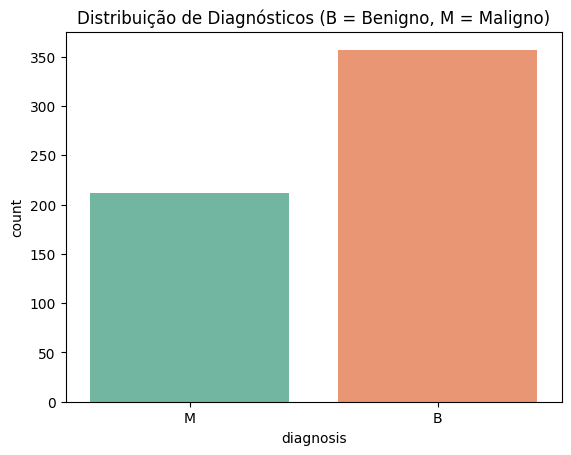

In [3]:
contagem = df['diagnosis'].value_counts()
percentual = df['diagnosis'].value_counts(normalize=True) * 100

print(contagem)
print(percentual.round(1))

sns.countplot(data=df, x='diagnosis', palette='Set2')
plt.title('Distribuição de Diagnósticos (B = Benigno, M = Maligno)')
plt.show()

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
radius1,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture1,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter1,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area1,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness1,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness1,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity1,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points1,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry1,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension1,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


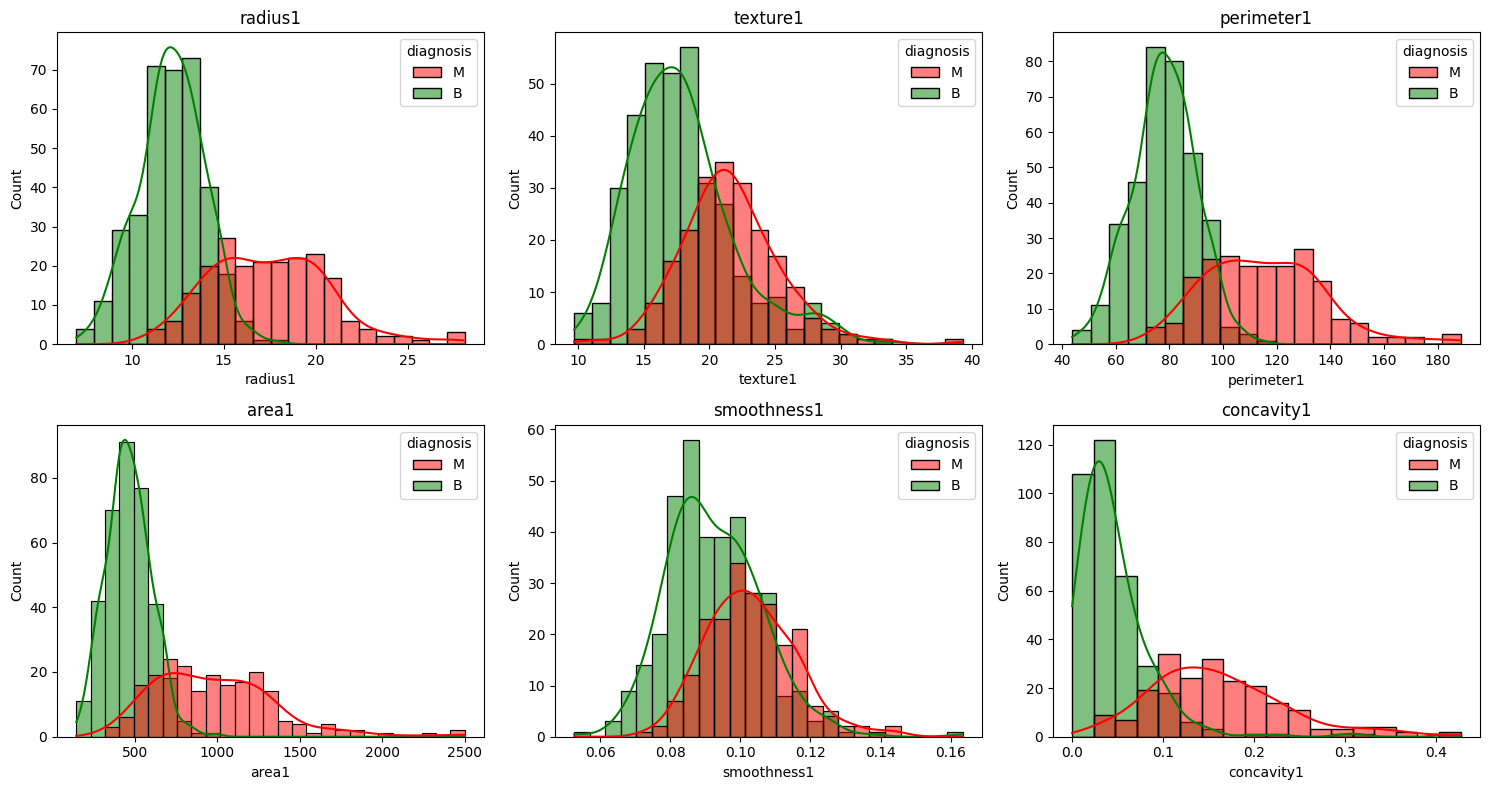

In [5]:
features_chave = ['radius1', 'texture1', 'perimeter1', 'area1', 
                   'smoothness1', 'concavity1']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features_chave):
    sns.histplot(data=df, x=feature, hue='diagnosis', kde=True, 
                 ax=axes[i], palette={'B': 'green', 'M': 'red'}, alpha=0.5)
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

## Conclusões da EDA

- Dataset com 569 registros, 30 features numéricas (10 características-base
  do núcleo celular, cada uma medida como média, erro padrão e "pior caso"),
  sem valores ausentes.
- Classes moderadamente desbalanceadas: 62.7% Benigno / 37.3% Maligno —
  ponto relevante para a escolha de métrica de avaliação na Etapa 4.
- Features como `radius`, `perimeter`, `area` e `concavity` mostram forte
  separação visual entre diagnósticos; `smoothness` mostra separação fraca.
- Grande disparidade de escala entre features → padronização necessária
  antes de modelos sensíveis a escala (próxima etapa).

